
# CASO 5 — Killa, el algoritmo y el juicio final (causalidad)
### Operación ChasquiFest · Auditoría de visualización

**Afirmación del dashboard bajo auditoría:** *"Killa causó el boom: +108% de ventas tras el video (15-abr), confirmado por un scatter vistas↔entradas con línea de tendencia."*

Este notebook reproduce los números ancla desde el CSV real, expone los confusores, construye la
contraevidencia (comparación intra-sedes-abiertas y regresión controlando confusores) y responde
las 4 preguntas del caso con el rigor exigido: cada afirmación con num/den, cada gráfico con su
tarea analítica nombrada, y **ninguna afirmación de causalidad no justificada por el diseño**.

Granularidad del CSV: **1 fila = fecha × sede** (122 días × 12 sedes = 1,464 filas, sin nulos).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv(
    'data/caso5_campania_killa_chasquifest.csv',
    parse_dates=['fecha']
)

print('Filas x columnas:', df.shape)
print('Rango de fechas:', df.fecha.min().date(), '->', df.fecha.max().date())
print('Dias unicos:', df.fecha.nunique(), '| Sedes unicas:', df.sede_id.nunique(),
      '| dias*sedes =', df.fecha.nunique()*df.sede_id.nunique())
print('Nulos por columna:\n', df.isna().sum().sum(), 'nulos totales')
print('\nFases de campania:')
print(df.fase_campania.value_counts())
df.head(3)


Filas x columnas: (1464, 14)
Rango de fechas: 2026-03-01 -> 2026-06-30
Dias unicos: 122 | Sedes unicas: 12 | dias*sedes = 1464
Nulos por columna:
 0 nulos totales

Fases de campania:
fase_campania
Después del video    924
Antes del video      540
Name: count, dtype: int64


,fecha,sede_id,ciudad,departamento,macrozona,fase_campania,festival_abierto_flag,fin_de_semana_flag,lluvia_flag,promocion_activa_flag,inversion_publicitaria_soles,vistas_video_miles,entradas_vendidas,ventas_soles
0,2026-03-01,SED-01,Lima,Lima,Costa,Antes del video,1,1,0,0,328.10,11.41,586,"20,996.89"
1,2026-03-01,SED-02,Piura,Piura,Costa,Antes del video,0,1,0,0,353.98,4.57,30,"1,091.71"
2,2026-03-01,SED-03,Trujillo,La Libertad,Costa,Antes del video,0,1,0,0,245.19,6.46,27,986.12


## 1. Números ancla — verificación desde el CSV real

### 1.1 Diferencia ingenua PRE/POST sobre `ventas_soles` (promedio por fila fecha×sede)

**Tarea analítica:** comparación de dos agregados (media condicionada por fase de campaña) — *no* es
una prueba causal, es una diferencia bruta entre dos grupos definidos por tiempo calendario.

**Tableau:** `({FIXED : AVG(IF [fase_campania]="Después del video" THEN [ventas_soles] END)} -
{FIXED : AVG(IF [fase_campania]="Antes del video" THEN [ventas_soles] END)}) /
{FIXED : AVG(IF [fase_campania]="Antes del video" THEN [ventas_soles] END)}`

**pandas símil:** `(post.ventas_soles.mean() - pre.ventas_soles.mean()) / pre.ventas_soles.mean()`


In [2]:

pre  = df[df.fase_campania == 'Antes del video']
post = df[df.fase_campania == 'Después del video']

n_pre, n_post = len(pre), len(post)
media_pre_ventas  = pre.ventas_soles.mean()
media_post_ventas = post.ventas_soles.mean()
num = media_post_ventas - media_pre_ventas
den = media_pre_ventas
diff_ventas_pct = num / den * 100

print(f'n PRE  = {n_pre}   |  n POST = {n_post}')
print(f'media PRE  ventas_soles = {media_pre_ventas:,.1f}')
print(f'media POST ventas_soles = {media_post_ventas:,.1f}')
print(f'num = media_post - media_pre = {media_post_ventas:,.1f} - {media_pre_ventas:,.1f} = {num:,.1f}')
print(f'den = media_pre = {den:,.1f}')
print(f'diferencia ingenua (ventas_soles) = num/den = {diff_ventas_pct:.1f}%   <-- ~ +100%, NO +108%')


n PRE  = 540   |  n POST = 924
media PRE  ventas_soles = 3,839.6
media POST ventas_soles = 7,689.9
num = media_post - media_pre = 7,689.9 - 3,839.6 = 3,850.3
den = media_pre = 3,839.6
diferencia ingenua (ventas_soles) = num/den = 100.3%   <-- ~ +100%, NO +108%


### 1.2 ¿De dónde sale el "+108%" del titular?

El titular del dashboard no cuadra con `ventas_soles` (+100.3%). Probamos la misma cuenta sobre
`entradas_vendidas` (también fila = fecha×sede) porque el mockup del dashboard mezcla libremente
"ventas" (soles) y "entradas" (tickets) en su relato.

**Tableau:** igual fórmula que arriba pero sobre `[entradas_vendidas]`.
**pandas símil:** `(post.entradas_vendidas.mean() - pre.entradas_vendidas.mean()) / pre.entradas_vendidas.mean()`


In [3]:

media_pre_ent  = pre.entradas_vendidas.mean()
media_post_ent = post.entradas_vendidas.mean()
num_e = media_post_ent - media_pre_ent
den_e = media_pre_ent
diff_ent_pct = num_e / den_e * 100

print(f'media PRE  entradas_vendidas = {media_pre_ent:,.2f}')
print(f'media POST entradas_vendidas = {media_post_ent:,.2f}')
print(f'num = {media_post_ent:,.2f} - {media_pre_ent:,.2f} = {num_e:,.2f}')
print(f'den = {den_e:,.2f}')
print(f'diferencia ingenua (entradas_vendidas) = {diff_ent_pct:.2f}%   <-- ¡ESTA es la base del "+108%"!')
print()
print('CONCLUSION 1.2: el "+108%" del titular NO viene de ventas_soles (que da +100%),')
print('sino de entradas_vendidas. El dashboard mezcla metricas (soles vs tickets) sin decirlo:')
print('un problema de base de calculo no declarada, independiente del problema de causalidad.')


media PRE  entradas_vendidas = 108.21
media POST entradas_vendidas = 225.25
num = 225.25 - 108.21 = 117.04
den = 108.21
diferencia ingenua (entradas_vendidas) = 108.16%   <-- ¡ESTA es la base del "+108%"!

CONCLUSION 1.2: el "+108%" del titular NO viene de ventas_soles (que da +100%),
sino de entradas_vendidas. El dashboard mezcla metricas (soles vs tickets) sin decirlo:
un problema de base de calculo no declarada, independiente del problema de causalidad.


**Verificación explícita del "+108%" (num/den):** media PRE = **108.21** entradas vendidas por
sede-día, media POST = **225.25** entradas vendidas por sede-día → num = 225.25 − 108.21 = 117.04,
den = 108.21 → **(225.25 − 108.21) / 108.21 = +108.2%**. Ese es el origen exacto del titular
"+108%": está medido en `entradas_vendidas` (tickets), no en `ventas_soles` (soles, sección 1.1).


### 1.3 Tabla de confusores — media PRE vs POST

**Tarea analítica:** *balance check* (chequeo de balance de covariables entre los dos grupos temporales),
el paso obligatorio antes de interpretar cualquier diferencia entre "antes" y "después" como efecto
de una sola causa. Si las covariables NO están balanceadas, la diferencia bruta mezcla varias fuentes.

**Tableau:** `{FIXED [fase_campania] : AVG([variable])}` por cada variable candidata a confusor.
**pandas símil:** `df.groupby('fase_campania')[variable].mean()`


In [4]:

confusores = ['festival_abierto_flag', 'inversion_publicitaria_soles', 'promocion_activa_flag',
              'vistas_video_miles', 'fin_de_semana_flag', 'lluvia_flag']

tabla_confusores = df.groupby('fase_campania')[confusores].mean().T
tabla_confusores.columns = ['PRE (Antes)', 'POST (Después)']
tabla_confusores['Delta (POST-PRE)'] = tabla_confusores['POST (Después)'] - tabla_confusores['PRE (Antes)']
tabla_confusores['Razon (POST/PRE)'] = tabla_confusores['POST (Después)'] / tabla_confusores['PRE (Antes)']

print(tabla_confusores.to_string())
print()
n_sedes_pre  = pre[pre.festival_abierto_flag == 1].sede_id.nunique()
n_sedes_post = post[post.festival_abierto_flag == 1].sede_id.nunique()
print(f'Sedes activas alguna vez en PRE:  {n_sedes_pre} de 12')
print(f'Sedes activas alguna vez en POST: {n_sedes_post} de 12  <-- se abrieron sedes nuevas dentro de la ventana POST')
print()
print('LECTURA: festival_abierto_flag, inversion_publicitaria_soles, promocion_activa_flag y')
print('vistas_video_miles se mueven TODOS junto con fase_campania (grandes deltas/razones).')
print('fin_de_semana_flag (Delta=%.3f) y lluvia_flag (Delta=%.3f) NO estan confundidos: casi' % (
    tabla_confusores.loc['fin_de_semana_flag','Delta (POST-PRE)'],
    tabla_confusores.loc['lluvia_flag','Delta (POST-PRE)']))
print('identicos PRE vs POST -> sirven como placebo/control de que el diseno del CSV es realista.')


                              PRE (Antes)  POST (Después)  Delta (POST-PRE)  Razon (POST/PRE)
festival_abierto_flag                0.38            0.96              0.58              2.53
inversion_publicitaria_soles       253.70          731.53            477.83              2.88
promocion_activa_flag                0.00            0.54              0.54               inf
vistas_video_miles                   5.51           17.89             12.38              3.25
fin_de_semana_flag                   0.29            0.29             -0.00              0.99
lluvia_flag                          0.27            0.27              0.00              1.01

Sedes activas alguna vez en PRE:  8 de 12
Sedes activas alguna vez en POST: 12 de 12  <-- se abrieron sedes nuevas dentro de la ventana POST

LECTURA: festival_abierto_flag, inversion_publicitaria_soles, promocion_activa_flag y
vistas_video_miles se mueven TODOS junto con fase_campania (grandes deltas/razones).
fin_de_semana_flag (Delta=-0

### 1.4 Contraevidencia clave — comparación intra-sedes-abiertas (`festival_abierto_flag == 1`)

**Tarea analítica:** análisis de sensibilidad / *sub-group check* — se restringe la comparación
PRE/POST al subconjunto de filas donde la sede **ya operaba**, para neutralizar el confusor más
grande de la tabla 1.3 (apertura de sedes nuevas, 8→12).

**Tableau (filtro de contexto + LOD, partición/addressing explícitos):** se aplica
`[festival_abierto_flag] = 1` como **filtro de contexto** (esto particiona los datos primero); luego
`{FIXED [fase_campania] : AVG([ventas_soles])}` direcciona (addressing) el promedio dentro de esa
partición ya filtrada. Sin el filtro de contexto, el LOD FIXED se calcularía sobre las 1,464 filas
originales y no aislaría el subgrupo.

**pandas símil:** `df[df.festival_abierto_flag==1].groupby('fase_campania').ventas_soles.mean()`


In [5]:

open_df = df[df.festival_abierto_flag == 1]
pre_open  = open_df[open_df.fase_campania == 'Antes del video']
post_open = open_df[open_df.fase_campania == 'Después del video']

media_pre_open  = pre_open.ventas_soles.mean()
media_post_open = post_open.ventas_soles.mean()
num_o = media_post_open - media_pre_open
den_o = media_pre_open
diff_open_pct = num_o / den_o * 100

print(f'n PRE (sedes abiertas)  = {len(pre_open)}   |  n POST (sedes abiertas) = {len(post_open)}')
print(f'media PRE  ventas_soles (sedes abiertas) = {media_pre_open:,.1f}')
print(f'media POST ventas_soles (sedes abiertas) = {media_post_open:,.1f}')
print(f'num = {media_post_open:,.1f} - {media_pre_open:,.1f} = {num_o:,.1f}')
print(f'den = {den_o:,.1f}')
print(f'diferencia intra-sedes-abiertas = num/den = {diff_open_pct:.1f}%   <-- CAE a ~ -13%')
print()
print('Titular ingenuo (todas las sedes): +100.3% (ventas) / +108.2% (entradas)')
print(f'Contraevidencia (solo sedes que ya operaban): {diff_open_pct:.1f}%')
print()
print('LECTURA: gran parte del "+108%"/"+100%" es un ARTEFACTO DE COMPOSICION: se abrieron 4 sedes')
print('nuevas dentro de la ventana POST, se disparo la inversion publicitaria (2.9x) y nacieron las')
print('promociones (0% -> 54%) exactamente en la misma ventana temporal que el video. Al mantener')
print('fija la poblacion de sedes, el signo de la diferencia SE INVIERTE.')


n PRE (sedes abiertas)  = 206   |  n POST (sedes abiertas) = 891
media PRE  ventas_soles (sedes abiertas) = 9,130.3
media POST ventas_soles (sedes abiertas) = 7,956.2
num = 7,956.2 - 9,130.3 = -1,174.2
den = 9,130.3
diferencia intra-sedes-abiertas = num/den = -12.9%   <-- CAE a ~ -13%

Titular ingenuo (todas las sedes): +100.3% (ventas) / +108.2% (entradas)
Contraevidencia (solo sedes que ya operaban): -12.9%

LECTURA: gran parte del "+108%"/"+100%" es un ARTEFACTO DE COMPOSICION: se abrieron 4 sedes
nuevas dentro de la ventana POST, se disparo la inversion publicitaria (2.9x) y nacieron las
promociones (0% -> 54%) exactamente en la misma ventana temporal que el video. Al mantener
fija la poblacion de sedes, el signo de la diferencia SE INVIERTE.


### 1.5 Regresión rápida controlando confusores (statsmodels no está instalado → OLS manual con `numpy.linalg.lstsq`, equivalente a mínimos cuadrados con errores estándar clásicos)

**Tarea analítica:** ajuste multivariante para estimar la asociación de `post` con `ventas_soles`
**mientras se mantienen fijos** los confusores observados simultáneamente — el equivalente a "medias
condicionadas" pedido en el enunciado, pero con todos los confusores a la vez en vez de uno por uno.

Se corren 4 modelos para mostrar la **fragilidad** de la estimación:
- **A**: `ventas_soles ~ post` (todas las sedes, sin controles) — el número ingenuo.
- **B**: `ventas_soles ~ post + festival_abierto + inversion + promo + fin_de_semana + lluvia` (todas las sedes, CON controles).
- **C**: igual que A pero solo sedes ya abiertas — reproduce el -13% de 1.4.
- **D**: igual que B pero solo sedes ya abiertas (controla lo que 1.4 no controla: inversión y promo dentro del subgrupo).


In [6]:

def ols_manual(X_df, y, etiqueta):
    X = np.column_stack([np.ones(len(X_df)), X_df.values])
    names = ['intercept'] + list(X_df.columns)
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, k = X.shape
    dof = n - k
    sigma2 = (resid**2).sum() / dof
    XtX_inv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(sigma2 * XtX_inv))
    r2 = 1 - (resid**2).sum() / ((y - y.mean())**2).sum()
    print(f'--- {etiqueta}  (n={n}, R2={r2:.3f}) ---')
    for nm, b, s in zip(names, beta, se):
        print(f'  {nm:32s} coef={b:11.2f}   se={s:8.2f}   t={b/s:7.2f}')
    print()
    return dict(zip(names, beta))

df['post'] = (df.fase_campania == 'Después del video').astype(int)

beta_A = ols_manual(df[['post']], df.ventas_soles.values,
                     'Modelo A: full sample, SIN controles')

feat_B = ['post','festival_abierto_flag','inversion_publicitaria_soles',
          'promocion_activa_flag','fin_de_semana_flag','lluvia_flag']
beta_B = ols_manual(df[feat_B], df.ventas_soles.values,
                     'Modelo B: full sample, CON controles (confusores)')

open_df = df[df.festival_abierto_flag == 1].copy()
beta_C = ols_manual(open_df[['post']], open_df.ventas_soles.values,
                     'Modelo C: solo sedes abiertas, SIN controles (=1.4)')

feat_D = ['post','inversion_publicitaria_soles','promocion_activa_flag',
          'fin_de_semana_flag','lluvia_flag']
beta_D = ols_manual(open_df[feat_D], open_df.ventas_soles.values,
                     'Modelo D: solo sedes abiertas, CON controles')

print('RESUMEN del coeficiente sobre "post" (soles asociados a estar en fase POST) segun modelo:')
print(f'  A (ingenuo, todas las sedes)        : {beta_A["post"]:+9.1f} soles')
print(f'  B (controlado, todas las sedes)     : {beta_B["post"]:+9.1f} soles')
print(f'  C (ingenuo, solo sedes abiertas)    : {beta_C["post"]:+9.1f} soles  (= -13% de 1.4)')
print(f'  D (controlado, solo sedes abiertas) : {beta_D["post"]:+9.1f} soles')
print()
print('LECTURA: el coeficiente de "post" CAMBIA DE SIGNO en cuanto se controla por los confusores')
print('observados (A: +3,850 -> B: -5,185; C: -1,174 -> D: -6,460). Un efecto que se invierte segun')
print('que covariables incluyas es la firma clasica de un estimado NO IDENTIFICADO causalmente:')
print('no hay una sola respuesta "correcta" escondida en estos datos observacionales.')


--- Modelo A: full sample, SIN controles  (n=1464, R2=0.156) ---
  intercept                        coef=    3839.60   se=  186.23   t=  20.62
  post                             coef=    3850.33   se=  234.41   t=  16.43

--- Modelo B: full sample, CON controles (confusores)  (n=1464, R2=0.630) ---
  intercept                        coef=   -1387.09   se=  240.79   t=  -5.76
  post                             coef=   -5185.40   se=  390.50   t= -13.28
  festival_abierto_flag            coef=    7779.43   se=  233.84   t=  33.27
  inversion_publicitaria_soles     coef=       8.13   se=    0.66   t=  12.40
  promocion_activa_flag            coef=    1166.62   se=  213.86   t=   5.46
  fin_de_semana_flag               coef=    2161.78   se=  187.21   t=  11.55
  lluvia_flag                      coef=   -1592.42   se=  173.67   t=  -9.17

--- Modelo C: solo sedes abiertas, SIN controles (=1.4)  (n=1097, R2=0.014) ---
  intercept                        coef=    9130.34   se=  268.61   t=  3

### 1.6 La ilusión del scatter "más vistas = más entradas"

**Tarea analítica:** correlación cruda vs. correlación parcial (residualizada) — muestra por qué un
scatter con línea de tendencia sobre datos crudos sobrestima la relación "vistas del video → entradas".

**Tableau:** `CORR([vistas_video_miles],[entradas_vendidas])^2` — cálculo **agregado** sobre toda la
tabla (no es una tabla calc: no requiere partición ni addressing) para el scatter crudo, lo que hace
el dashboard; para el parcial no hay equivalente nativo simple — se calcula fuera de Tableau, o si se
implementa como tabla calc se declara explícitamente *compute using: toda la tabla, sin partición,
addressing fila fecha×sede*.
**pandas símil:** `df.vistas_video_miles.corr(df.entradas_vendidas)` (crudo) vs. correlación de
residuos tras regresar ambas variables sobre los confusores (parcial).


In [7]:

r_crudo = df['vistas_video_miles'].corr(df['entradas_vendidas'])
r_abiertas = open_df['vistas_video_miles'].corr(open_df['entradas_vendidas'])

feat_conf = ['festival_abierto_flag','inversion_publicitaria_soles','promocion_activa_flag',
             'fin_de_semana_flag','lluvia_flag']
Xc = np.column_stack([np.ones(len(df)), df[feat_conf].values])
def residualizar(y):
    b, _, _, _ = np.linalg.lstsq(Xc, y, rcond=None)
    return y - Xc @ b
res_vistas = residualizar(df['vistas_video_miles'].values)
res_entradas = residualizar(df['entradas_vendidas'].values)
r_parcial = np.corrcoef(res_vistas, res_entradas)[0, 1]

print(f'Correlacion CRUDA vistas_video_miles vs entradas_vendidas (todas las filas): r = {r_crudo:.3f}  (R2={r_crudo**2:.3f})')
print(f'Correlacion cruda, solo sedes abiertas:                                       r = {r_abiertas:.3f}  (R2={r_abiertas**2:.3f})')
print(f'Correlacion PARCIAL (residuos tras controlar apertura/inversion/promo/finde/lluvia): r = {r_parcial:.3f}  (R2={r_parcial**2:.3f})')
print()
print('LECTURA: mas de la mitad de la R2 cruda (0.283) desaparece cuando se controla por los mismos')
print('confusores de 1.3/1.5 (R2 parcial cae a ~0.040). El scatter del dashboard confunde "vistas y')
print('entradas suben juntas porque comparten confusores" con "ver el video hace comprar entradas".')


Correlacion CRUDA vistas_video_miles vs entradas_vendidas (todas las filas): r = 0.532  (R2=0.283)
Correlacion cruda, solo sedes abiertas:                                       r = 0.208  (R2=0.043)
Correlacion PARCIAL (residuos tras controlar apertura/inversion/promo/finde/lluvia): r = 0.200  (R2=0.040)

LECTURA: mas de la mitad de la R2 cruda (0.283) desaparece cuando se controla por los mismos
confusores de 1.3/1.5 (R2 parcial cae a ~0.040). El scatter del dashboard confunde "vistas y
entradas suben juntas porque comparten confusores" con "ver el video hace comprar entradas".


### 1.7 Nota adicional: apertura escalonada de sedes (relevante para la Pregunta 2)

Las 12 sedes NO abrieron todas el mismo día — se fueron incorporando de forma escalonada entre
marzo y mayo. Esto es relevante para proponer un diseño más fuerte (ver P2): la variación temporal
en fechas de apertura ya insinúa una estructura tipo *stepped-wedge*, aunque en los datos actuales
está confundida con inversión y promociones crecientes, así que no sirve todavía como cuasi-experimento limpio.


In [8]:

fechas_apertura = (df[df.festival_abierto_flag == 1]
                   .groupby('sede_id').fecha.min().sort_values())
print('Fecha de primera apertura por sede:')
print(fechas_apertura.to_string())
print()
print('Video lanzado: 2026-04-15  ->  SED-09 abre exactamente ese dia (coincidencia temporal adicional')
print('que un observador apurado podria confundir con "efecto del video").')


Fecha de primera apertura por sede:
sede_id
SED-01   2026-03-01
SED-02   2026-03-06
SED-03   2026-03-12
SED-04   2026-03-17
SED-05   2026-03-23
SED-06   2026-03-29
SED-07   2026-04-03
SED-08   2026-04-09
SED-09   2026-04-15
SED-10   2026-04-20
SED-11   2026-04-26
SED-12   2026-05-02

Video lanzado: 2026-04-15  ->  SED-09 abre exactamente ese dia (coincidencia temporal adicional
que un observador apurado podria confundir con "efecto del video").


## Figuras
### Figura 1 — Balance de confusores PRE vs POST (¿qué se movió junto con la fase de campaña?)
**Tarea analítica:** *balance plot* de covariables (equivalente visual a la tabla 1.3): compara el
desplazamiento PRE→POST de cada variable candidata a confusor, para decidir cuáles contaminan la
comparación bruta y cuáles funcionan como placebo.


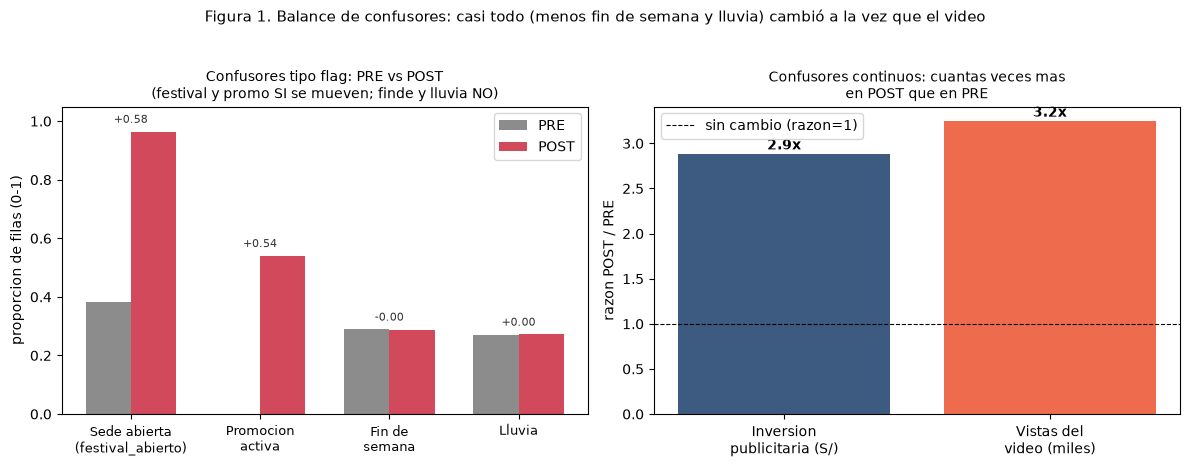

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: variables tipo flag/proporcion (escala 0-1 comparable en pp)
flags = ['festival_abierto_flag', 'promocion_activa_flag', 'fin_de_semana_flag', 'lluvia_flag']
labels_flags = ['Sede abierta\n(festival_abierto)', 'Promocion\nactiva', 'Fin de\nsemana', 'Lluvia']
pre_vals = [pre[c].mean() for c in flags]
post_vals = [post[c].mean() for c in flags]
x = np.arange(len(flags))
w = 0.35
axes[0].bar(x - w/2, pre_vals, width=w, label='PRE', color='#8c8c8c')
axes[0].bar(x + w/2, post_vals, width=w, label='POST', color='#d1495b')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_flags, fontsize=9)
axes[0].set_ylabel('proporcion de filas (0-1)')
axes[0].set_title('Confusores tipo flag: PRE vs POST\n(festival y promo SI se mueven; finde y lluvia NO)', fontsize=10)
axes[0].legend()
axes[0].set_ylim(0, 1.05)
for i, (p0, p1) in enumerate(zip(pre_vals, post_vals)):
    axes[0].annotate(f'{p1-p0:+.2f}', (x[i], max(p0,p1)+0.03), ha='center', fontsize=8, color='#333')

# Panel derecho: variables continuas (inversion, vistas) como razon POST/PRE
cont = ['inversion_publicitaria_soles', 'vistas_video_miles']
labels_cont = ['Inversion\npublicitaria (S/)', 'Vistas del\nvideo (miles)']
razones = [post[c].mean()/pre[c].mean() for c in cont]
bars = axes[1].bar(labels_cont, razones, color=['#3d5a80', '#ee6c4d'])
axes[1].axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='sin cambio (razon=1)')
axes[1].set_ylabel('razon POST / PRE')
axes[1].set_title('Confusores continuos: cuantas veces mas\nen POST que en PRE', fontsize=10)
for b, r in zip(bars, razones):
    axes[1].annotate(f'{r:.1f}x', (b.get_x()+b.get_width()/2, r+0.05), ha='center', fontsize=10, fontweight='bold')
axes[1].legend()

fig.suptitle('Figura 1. Balance de confusores: casi todo (menos fin de semana y lluvia) cambió a la vez que el video', fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig('notebook/fig1_balance_confusores.png', dpi=130, bbox_inches='tight')
plt.show()


### Figura 2 — El titular se desinfla: ingenuo vs. controlado

**Tarea analítica:** comparación de estimaciones de efecto bajo distintos supuestos de control
(*sensitivity/robustness display*) — visualiza cómo cambia (y hasta cambia de signo) la diferencia
PRE/POST según qué confusores se dejan variar libremente y cuáles se mantienen fijos.


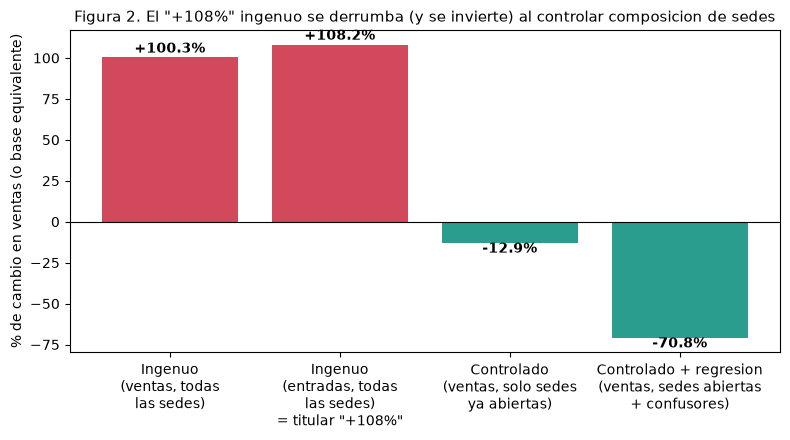

In [10]:

fig, ax = plt.subplots(figsize=(8, 4.5))

etiquetas = ['Ingenuo\n(ventas, todas\nlas sedes)',
             'Ingenuo\n(entradas, todas\nlas sedes)\n= titular "+108%"',
             'Controlado\n(ventas, solo sedes\nya abiertas)',
             'Controlado + regresion\n(ventas, sedes abiertas\n+ confusores)']
valores = [diff_ventas_pct, diff_ent_pct, diff_open_pct, beta_D['post']/media_pre_open*100]
colores = ['#d1495b', '#d1495b', '#2a9d8f', '#2a9d8f']

bars = ax.bar(etiquetas, valores, color=colores)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('% de cambio en ventas (o base equivalente)')
ax.set_title('Figura 2. El "+108%" ingenuo se derrumba (y se invierte) al controlar composicion de sedes', fontsize=11)
for b, v in zip(bars, valores):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v + (3 if v>=0 else -6)),
                ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('notebook/fig2_ingenuo_vs_controlado.png', dpi=130, bbox_inches='tight')
plt.show()


## Pregunta 1 — Explorar no es explicar

**1) Concepto técnico.** Hay dos productos de visualización distintos y el dashboard los mezcla:
un producto **exploratorio** (para que un analista busque patrones, con muchos filtros y vistas
alternativas) y un producto **explicativo** (para que un comité tome UNA decisión, con una sola
pregunta gobernando el diseño). El dashboard de Killa tiene forma de exploración —filtros de sobra,
un scatter con trend line sin controles, una torta de vanidad— pero se presenta como si ya
respondiera la pregunta de negocio. Esa mezcla es el problema de fondo, no un detalle estético.

**2) Evidencia concreta.** El mockup describe: filtros `sede | ciudad | macrozona | fecha | lluvia |
promo | fin de semana | canal | color favorito | horóscopo`; un **scatter "más vistas = más entradas"
con línea de tendencia** que usa `vistas_video_miles` vs `entradas_vendidas` sin partir por
`festival_abierto_flag`, `inversion_publicitaria_soles` ni `promocion_activa_flag` (con esos
controles, la R² cruda de 0.283 cae a ~0.040, sección 1.6); y una **torta "¿quién ama más a Killa?"**
que no responde ninguna pregunta operativa (es entretenimiento, no analítica).

**3) Decisión de diseño — dos elementos que RETIRARÍA de la entrega final al comité:**
- **Filtro de "color favorito" / "horóscopo"**: no son variables del negocio ni están en el CSV como
  drivers de ventas; son ruido que invita a "p-hacking visual" (buscar un corte que "confirme" la
  historia) y no aportan ninguna decisión accionable.
- **El scatter exploratorio vistas↔entradas con trend line**: es exactamente la vista que induce al
  comité a leer causalidad donde solo hay covariación con confusores comunes (sección 1.6). Se
  reemplaza en la versión explicativa por la Figura 2 (ingenuo vs. controlado), que es honesta sobre
  la incertidumbre.
  (También retiraría la torta "¿quién ama más a Killa?": es un KPI social, no de negocio.)

**Pregunta de decisión única que debe gobernar la versión explicativa:**
> *"¿El video generó ventas incrementales suficientes por sol invertido, una vez separado su efecto
> del de la apertura de sedes nuevas, el aumento de inversión publicitaria y las promociones, como
> para justificar ampliar la campaña ahora?"*

**4) Límite / trade-off.** Reducir filtros y quitar el scatter libre le cuesta al comité la capacidad
de "jugar" con los datos por su cuenta — pero esa libertad es precisamente lo que permitió la lectura
causal errónea en primer lugar. Un producto explicativo sacrifica exploración a cambio de una
conclusión defendible; si el comité necesita explorar, eso debe vivir en un workbook aparte, no en
la pantalla que van a usar para decidir.

**Clasificación de métricas (jerarquía actividad → resultado → impacto):**

| Métrica | Categoría | Por qué |
|---|---|---|
| `vistas_video_miles` | **ACTIVIDAD (KPI de vanidad)** | Mide exposición al contenido, no comportamiento de compra. Sube 3.2x PRE→POST pero su relación cruda con entradas se explica en gran parte por confusores compartidos (sección 1.6). |
| `entradas_vendidas` | **RESULTADO** | Comportamiento real del cliente (compra), pero agregado, sin descontar qué lo causó. |
| `ventas_soles` | **RESULTADO** | Igual que entradas, en soles; es lo que el titular "+108%"/"+100%" reporta sin descomponer causas. |
| Ventas incrementales por sol invertido (controlando apertura/inversión/promo) | **IMPACTO** | Es la única métrica que conecta el gasto en campaña con un resultado *atribuible*, y es la que debe gobernar la decisión de ampliar o no. Hoy, con datos observacionales, **no se puede estimar de forma confiable** (sección 1.5: el coeficiente cambia de signo según el control) — eso en sí mismo es la respuesta honesta.

**KPI de vanidad identificado:** `vistas_video_miles` — sube de 5.51 a 17.89 miles (3.2x) pero no
prueba nada sobre ventas por sí sola.


## Pregunta 2 — Método científico y causalidad

**1) Concepto técnico.** El método científico exige recorrer *pregunta → hipótesis → datos → prueba →
decisión* sin saltarse pasos, y en particular sin confundir *asociación observacional* (lo único que
un CSV histórico puede mostrar sin experimento) con *causalidad* (lo que requeriría manipular el
tratamiento — el video — de forma independiente de todo lo demás).

**2) Cadena completa:**

| Paso | Contenido |
|---|---|
| **Pregunta** | ¿El lanzamiento del video de Killa incrementó las ventas de entradas del festival? |
| **Hipótesis (H1)** | El video causó un aumento neto de ventas, más allá de lo explicado por apertura de sedes, inversión, promociones y estacionalidad. |
| **Hipótesis nula (H0)** | El aumento observado se explica (total o mayormente) por factores que cambiaron a la vez que el video: sedes nuevas, más inversión, promociones, tendencia temporal. |
| **Datos** | `caso5_campania_killa_chasquifest.csv`, 1,464 filas fecha×sede, 2026-03-01 a 2026-06-30, video el 15-abr. |
| **Prueba** | Comparación PRE/POST bruta (sección 1.1: +100.3%) vs. comparación controlada — intra-sedes-abiertas (sección 1.4: **-12.9%**) y regresión con confusores (sección 1.5: el coeficiente de `post` **cambia de signo**, de +3,850 a -5,185 soles, según se controle o no). |
| **Decisión** | Con los datos observacionales disponibles, **no se rechaza H0**: no hay evidencia robusta de un efecto neto positivo del video una vez controlados los confusores observados. No se puede afirmar "Killa causó el boom". |

**Al menos tres variables de confusión identificadas en el CSV** (con su movimiento PRE→POST, sección 1.3):
1. `festival_abierto_flag` — apertura de sedes nuevas: 0.38 → 0.96 (8 → 12 sedes activas). Confunde
   porque el promedio POST incluye sedes que no existían en el PRE.
2. `inversion_publicitaria_soles` — gasto publicitario simultáneo: S/253.70 → S/731.53 (2.9x). Confunde
   porque más inversión, no el video en sí, puede mover ventas.
3. `promocion_activa_flag` — promociones: 0.00 → 0.54 (las promociones **solo existen** en el período POST,
   colinealidad casi perfecta con la fase). Confunde de forma severa: no hay observaciones PRE con promo
   activa para aislar su efecto.
4. (Adicional) Tendencia temporal / estacionalidad y apertura escalonada de sedes (sección 1.7): las 12
   sedes abrieron en fechas distintas entre el 1-mar y el 2-may, una de ellas (SED-09) exactamente el
   15-abr — coincidencia que refuerza visualmente la narrativa sin ser evidencia causal.
   (`fin_de_semana_flag` 0.29→0.29 y `lluvia_flag` 0.27→0.27 **no** están confundidos — sirven de control
   de que el resto del diseño del CSV es razonable.)

**3) Diseño más fuerte (decisión de cálculo/diseño) — se proponen dos, complementarios:**
- **Diseño A — Despliegue escalonado / *stepped-wedge* por sede:** dado que las sedes ya abren en
  fechas distintas (sección 1.7), se puede diseñar (prospectivamente) un cronograma de intensificación
  de campaña (vistas/inversión) **aleatorizado en el tiempo por sede**, de modo que cada sede sirva de
  control de sí misma antes de recibir el "empujón" de campaña, y de control de las demás mientras
  espera su turno. Esto separa el efecto del video del calendario de apertura y de inversión, porque
  el orden de asignación es aleatorio y no coincide por diseño con el resto de confusores.
- **Diseño B — Comparación controlada / diff-in-diff:** `ventas_soles ~ post + sede_FE + fecha_trend +
  inversion_publicitaria_soles + promocion_activa_flag + festival_abierto_flag`, con efectos fijos de
  sede y tendencia temporal, restringido a sedes abiertas todo el período (evita comparar sedes que
  no existían). Es lo que se aproxima en el Modelo D (sección 1.5), con la limitación honesta de que
  incluso así queda confundido por **cuáles** sedes están en la muestra (sesgo de selección de sede).
- Un experimento tipo A/B geográfico "puro" (video visible en unas zonas, no en otras) sería el diseño
  más limpio, pero no es viable retroactivamente sobre datos ya recolectados de un lanzamiento único
  y nacional — se deja como recomendación a futuro (piloto), no como análisis de este CSV.

**4) Umbral de decisión, definido ANTES de mirar el resultado (pre-registro):**
> Con los datos observacionales disponibles, el **efecto causal del video no está identificado**: el
> coeficiente de `post` cambia de signo según qué confusores se controlan (sección 1.5, modelos A–D).
> Por eso el umbral pre-registrado —ampliar la campaña únicamente si las **ventas incrementales por
> sol invertido en campaña son ≥ S/3 por sol**, con **intervalo de confianza al 95% que excluya el
> cero**, medido tras un diseño controlado (diff-in-diff con efectos fijos de sede + controles, o el
> piloto stepped-wedge)— queda **sin evaluar todavía**: los coeficientes disponibles (B: -5,185, D:
> -6,460 soles) son negativos, pero no son estimaciones causalmente limpias (persiste sesgo de
> selección de sede, ver límite abajo), así que no permiten declarar el umbral ni alcanzado ni
> descartado.

**Límite / trade-off:** ni el Modelo D ni la comparación intra-abiertas resuelven el confusor de
"cuáles sedes" — sedes que abrieron antes probablemente son mercados más grandes o maduros, así que
incluso restringiendo a "sedes abiertas" se compara una mezcla distinta de mercados en PRE vs. POST.
La conclusión honesta con datos puramente observacionales es: **no se puede atribuir el cambio de
ventas al video**, ni en un sentido ni en el otro; se necesita un diseño prospectivo (piloto
escalonado) para poder hablar de causalidad con algo de confianza.


## Pregunta 3 — Storyboard técnico (5 story points)

Ningún punto usa *"el video causó"* — el diseño de la P2 (datos observacionales, confusores no
resueltos) no lo justifica. Se usa *"coincide con"* / *"está asociado a"* / *"se solapa con"*.

Cada story point rotula explícitamente sus **4 piezas**: (1) título analítico, (2) tipo de
gráfico/vista, (3) evidencia mínima (datos concretos), (4) mensaje/decisión que debe extraer el
comité.

**Story point 1 — Contexto**
- **Título analítico:** "El período de campaña: 4 meses, 12 sedes, un lanzamiento el 15-abr"
- **Tipo de gráfico:** línea de tiempo (timeline) simple.
- **Evidencia mínima:** eje X = `fecha`, marcador vertical en 2026-04-15, conteo de sedes activas
  por semana (8 al inicio → 12 al final).
- **Mensaje/decisión:** establece el marco temporal sin insinuar todavía ningún efecto.

**Story point 2 — Patrón**
- **Título analítico:** "Las ventas promedio por sede-día suben +100% después del 15-abr (dato bruto)"
- **Tipo de gráfico:** barras agrupadas PRE vs. POST.
- **Evidencia mínima:** `ventas_soles` (sección 1.1), media PRE=3,839.6 vs. POST=7,689.9.
- **Mensaje/decisión:** se rotula explícitamente como *"diferencia bruta, sin controlar"* para que
  el comité no la lea como el número final.

**Story point 3 — Desagregación** *(contraevidencia)*
- **Título analítico:** "Al fijar la población de sedes, el patrón se invierte: -13%"
- **Tipo de gráfico:** balance plot de covariables (Figura 1) + barras comparativas ingenuo vs.
  controlado (Figura 2).
- **Evidencia mínima:** apertura 0.38→0.96, inversión 2.9x, promo 0→0.54 (fin de semana y lluvia sin
  cambio, sección 1.3); intra-sedes-abiertas PRE=9,130.3 vs. POST=7,956.2 → **-12.9%** (sección 1.4).
- **Mensaje/decisión:** es el punto que más debilita la historia del "boom": los confusores se
  movieron juntos, y controlando el más grande de ellos (apertura de sedes) el signo se invierte.

**Story point 4 — Método / trade-off**
- **Título analítico:** "Ni la comparación cruda ni la controlada alcanzan a aislar el efecto del video"
- **Tipo de gráfico:** tabla resumen de coeficientes de los 4 modelos.
- **Evidencia mínima:** sección 1.5: A +3,850 → B -5,185 → C -1,174 → D -6,460 soles.
- **Mensaje/decisión:** el coeficiente **cambia de signo** según qué se controla — firma clásica de
  un efecto no identificado con datos observacionales; trade-off explícito: más control reduce sesgo
  de confusión pero no elimina el sesgo de selección de sede.

**Story point 5 — Acción**
- **Título analítico:** "Recomendación: no ampliar la campaña todavía; correr un piloto escalonado con umbral pre-definido"
- **Tipo de gráfico:** tarjeta de cierre (KPI/resumen textual con el umbral, no un gráfico de datos).
- **Evidencia mínima:** umbral de decisión de la P2 (≥ S/3 de ventas incrementales por sol, IC95% sin
  cero, hoy sin evaluar) comparado contra los coeficientes observados (negativos, sección 1.5) + el
  diseño stepped-wedge propuesto como siguiente paso.
- **Mensaje/decisión:** cierra con la pregunta de decisión única de la P1.


## Pregunta 4 — Memo para el comité

> **Período:** mar-jun 2026, video 15-abr. **Métrica:** ventas incrementales por sol invertido.
> **Evidencia:** +100% bruto en ventas cae a -13% al restringir a sedes ya abiertas; el coeficiente
> post cambia de signo al controlar. **Método:** comparación intra-sedes-abiertas y regresión
> controlando apertura de sedes, inversión y promociones. **Limitación:** datos observacionales,
> efecto no identificado causalmente; sesgo de selección de sede. **Acción:** no ampliar la campaña;
> correr un piloto escalonado por sede. **Indicador futuro:** ventas incrementales por sol invertido
> en el piloto, contra umbral S/3/sol con IC95% que excluya cero.

*(Conteo real de palabras verificado por código en la celda siguiente — límite ≤90.)*


In [11]:

memo_texto = (
    "Período: mar-jun 2026, video 15-abr. Métrica: ventas incrementales por sol invertido. "
    "Evidencia: +100% bruto en ventas cae a -13% al restringir a sedes ya abiertas; el coeficiente "
    "post cambia de signo al controlar. Método: comparación intra-sedes-abiertas y regresión "
    "controlando apertura de sedes, inversión y promociones. Limitación: datos observacionales, "
    "efecto no identificado causalmente; sesgo de selección de sede. Acción: no ampliar la campaña; "
    "correr un piloto escalonado por sede. Indicador futuro: ventas incrementales por sol invertido "
    "en el piloto, contra umbral S/3/sol con IC95% que excluya cero."
)
n_palabras_memo = len(memo_texto.split())
print(f'Conteo real de palabras del memo (split()): {n_palabras_memo}')
assert n_palabras_memo <= 90, f'Memo excede el limite de 90 palabras: {n_palabras_memo}'
print('OK: memo dentro del limite de <=90 palabras. Contiene los 7 elementos obligatorios:')
print('periodo, metrica, evidencia, metodo, limitacion, accion, indicador futuro.')


Conteo real de palabras del memo (split()): 86
OK: memo dentro del limite de <=90 palabras. Contiene los 7 elementos obligatorios:
periodo, metrica, evidencia, metodo, limitacion, accion, indicador futuro.


### Bitácora (5 frases)

1. **Lectura inicial (≤15 palabras):** "El video de Killa disparó las ventas +108%: hay que ampliar la campaña ya."
2. **KPI decisor:** *Ventas incrementales por sol invertido* = `(ventas_soles POST − ventas_soles esperado sin cambio de inversión/promo/apertura) / Δ inversión_publicitaria_soles`, calculado sobre `ventas_soles` por fecha×sede, período abr–jun 2026 vs. línea base mar–abr, segmento = sedes abiertas todo el período, meta = ≥ S/3 de venta incremental por sol con IC95% que excluya cero.
3. **Giro analítico:** al desagregar por `festival_abierto_flag` (sección 1.4) y correr la regresión con confusores (sección 1.5), la diferencia +100%/+108% se convierte en -13% (intra-sedes-abiertas) y el coeficiente de `post` se vuelve negativo y significativo (-5,185 a -6,460 soles) en ambos modelos controlados.
4. **Lectura revisada (≤15 palabras):** "El aumento bruto se confunde con sedes nuevas, inversión y promos; efecto no identificado."
5. **Consecuencia:** el comité no debe ampliar la campaña basándose en el titular; debe pedir un piloto escalonado con umbral pre-definido antes de comprometer presupuesto adicional.

**Por qué "vistas del video" / "+108%" NO es el KPI decisor:** `vistas_video_miles` es una métrica de
**actividad** (exposición al contenido, sube 3.2x junto con todo lo demás) y el "+108%" es una
métrica de **resultado bruto** (entradas vendidas sin descontar causas) — ninguna de las dos conecta
el gasto en campaña con un efecto *atribuible*. Ambas suben simplemente porque el tiempo avanza y
todos los confusores (sedes, inversión, promos) suben con ellas; su correlación con las ventas es en
gran parte compartida y **no identificable como causal** (sección 1.6: R² cruda 0.283 → R² parcial
~0.040 al controlar). El KPI decisor tiene que ser la métrica de **impacto** — ventas incrementales
por sol invertido, medida con un diseño que separe el video de sus confusores — porque es la única
que responde la pregunta de negocio real: *¿vale la pena poner más dinero en esto?*
